In [1]:
!pip install pandas openpyxl langchain langgraph langchain-openai

     -------------------------------------- 161.5/161.5 kB 3.2 MB/s eta 0:00:00
     -------------------------------------- 571.8/571.8 kB 9.1 MB/s eta 0:00:00
  Attempting uninstall: langchain-core
    Found existing installation: langchain-core 1.5.3
    Uninstalling langchain-core-1.5.3:
      Successfully uninstalled langchain-core-1.5.3



[notice] A new release of pip available: 22.3.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import os

from typing import TypedDict, Annotated
from langchain_core.messages import HumanMessage
from langchain_core.tools import tool
from langchain_openai import ChatOpenAI

from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode

In [3]:
portfolio_df = pd.read_excel("portfolio.xlsx")

portfolio_df.head()

,Symbol,Quantity,AvgPrice,Sector
0,TCS,10,3500,IT
1,HDFCBANK,20,1500,Banking


In [4]:
portfolio_df["Investment"] = (
    portfolio_df["Quantity"]
    * portfolio_df["AvgPrice"]
)

portfolio_df.head()

,Symbol,Quantity,AvgPrice,Sector,Investment
0,TCS,10,3500,IT,35000
1,HDFCBANK,20,1500,Banking,30000


In [6]:
def total_investment(df):
    return df["Investment"].sum()

def total_holdings(df):
    return len(df)

def largest_holding(df):

    row = df.loc[df["Investment"].idxmax()]

    return {
        "symbol": row["Symbol"],
        "investment": float(row["Investment"])
    }

def sector_allocation(df):

    result = (
        df.groupby("Sector")["Investment"]
        .sum()
        .sort_values(ascending=False)
    )

    return result.to_dict()



In [7]:
@tool
def get_total_investment():
    """
    Returns total invested amount.
    """

    return float(total_investment(portfolio_df))

@tool
def get_total_holdings():
    """
    Returns number of holdings.
    """

    return total_holdings(portfolio_df)

@tool
def get_largest_holding():
    """
    Returns largest holding.
    """

    return largest_holding(portfolio_df)

@tool
def get_sector_allocation():
    """
    Returns sector allocation.
    """

    return sector_allocation(portfolio_df)

In [8]:
tools = [
    get_total_investment,
    get_total_holdings,
    get_largest_holding,
    get_sector_allocation
]

In [10]:
llm_with_tools = llm.bind_tools(tools)

In [19]:
from typing import Annotated
from typing_extensions import TypedDict

from langgraph.graph.message import add_messages


class PortfolioState(TypedDict):
    messages: Annotated[list, add_messages]

In [20]:
def chatbot(state):

    response = llm_with_tools.invoke(
        state["messages"]
    )

    return {
        "messages": state["messages"] + [response]
    }

In [21]:
tool_node = ToolNode(tools)

In [22]:
def route_tools(state):

    last_message = state["messages"][-1]

    if hasattr(last_message, "tool_calls") and last_message.tool_calls:
        return "tools"

    return END

In [23]:
graph_builder = StateGraph(PortfolioState)

graph_builder.add_node(
    "chatbot",
    chatbot
)

graph_builder.add_node(
    "tools",
    tool_node
)

graph_builder.add_edge(
    START,
    "chatbot"
)

graph_builder.add_conditional_edges(
    "chatbot",
    route_tools
)

graph_builder.add_edge(
    "tools",
    "chatbot"
)

graph = graph_builder.compile()

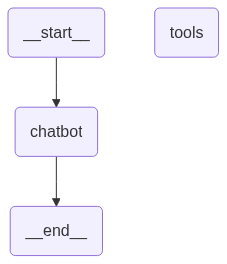

In [24]:
graph

In [25]:
def ask_portfolio(question):

    response = graph.invoke(
        {
            "messages": [
                HumanMessage(content=question)
            ]
        }
    )

    return response["messages"][-1].content

In [26]:
ask_portfolio(
    "What is my total investment?"
)

'Your total investment is $65,000.'

In [27]:
ask_portfolio(
    "Which stock is my largest holding?"
)

'Your largest holding is TCS, with an investment of $35,000.'